In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import kstest_normal, het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.anova import anova_lm
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector
from PIL import Image
import io


df_boston = pd.read_csv('BostonHousing.csv')
df_boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [2]:
print(df_boston.describe())

             crim          zn       indus        chas         nox          rm  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              age         dis         rad         tax     ptratio           b  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032   
std     28.148861    2.1057

In [3]:
df_boston.rename(columns={'b': 'B', 'medv': 'MEDV'}, inplace=True)
df_boston.rename(columns={'crim':"crime_rate", 'zn':"land_rate", 'indus':"comercial_acre_rate", 'chas':"river", 'nox':"nitro_ox", 'rm':"room_per_house", 'age':"age", 'dis':"job_dist", 'rad':"road_index", 'tax':"tax_rate", 'ptratio':"teacher_student_ratio", 'lstat':"low_inc_perc"}, inplace=True)
df_boston.head()
print("\nVariables en el dataset:")
print(df_boston.columns)


Variables en el dataset:
Index(['crime_rate', 'land_rate', 'comercial_acre_rate', 'river', 'nitro_ox',
       'room_per_house', 'age', 'job_dist', 'road_index', 'tax_rate',
       'teacher_student_ratio', 'B', 'low_inc_perc', 'MEDV'],
      dtype='object')


In [4]:
df_boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   crime_rate             506 non-null    float64
 1   land_rate              506 non-null    float64
 2   comercial_acre_rate    506 non-null    float64
 3   river                  506 non-null    int64  
 4   nitro_ox               506 non-null    float64
 5   room_per_house         506 non-null    float64
 6   age                    506 non-null    float64
 7   job_dist               506 non-null    float64
 8   road_index             506 non-null    int64  
 9   tax_rate               506 non-null    int64  
 10  teacher_student_ratio  506 non-null    float64
 11  B                      506 non-null    float64
 12  low_inc_perc           506 non-null    float64
 13  MEDV                   506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


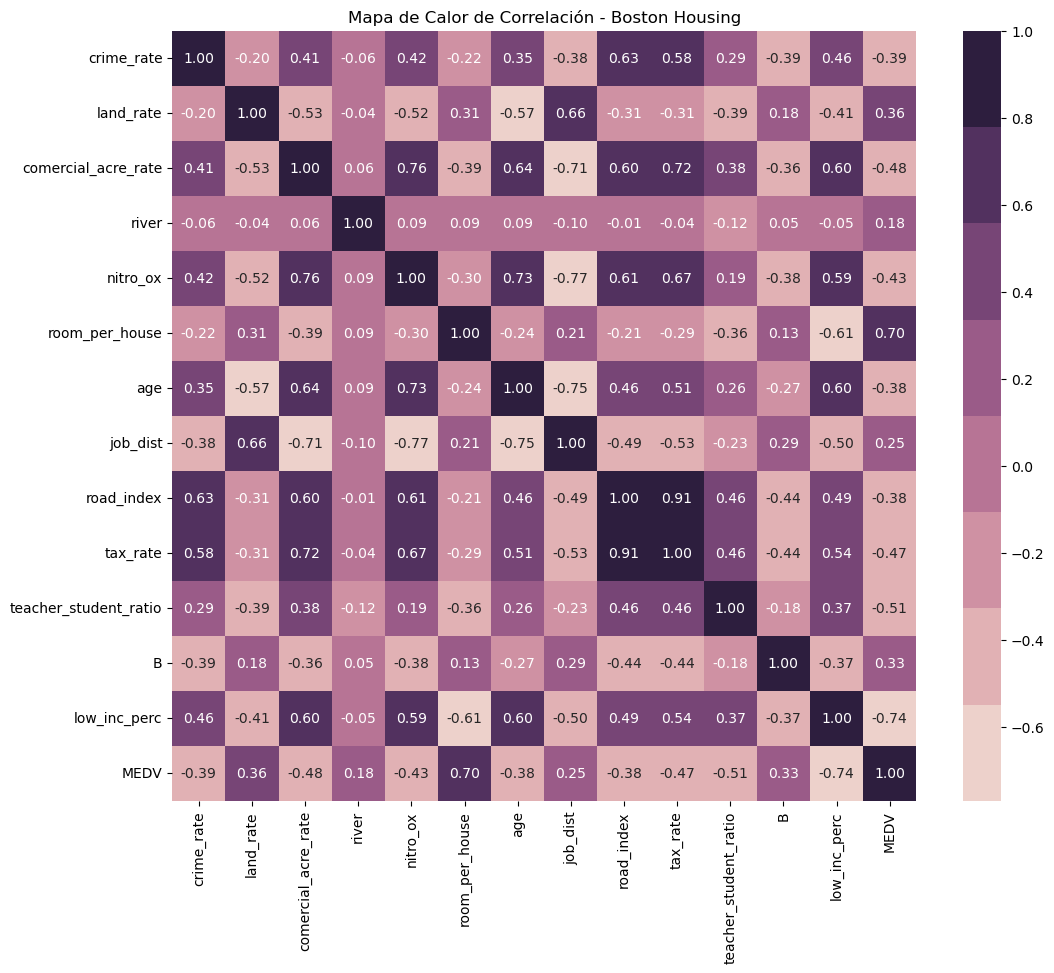

<Figure size 640x480 with 0 Axes>

In [5]:
corr_matrix = df_boston.corr()
default_cube = sns.cubehelix_palette(8) 
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap=default_cube, fmt='.2f')
plt.title('Mapa de Calor de Correlación - Boston Housing')
plt.show()
plt.savefig("mapadecalor.png")

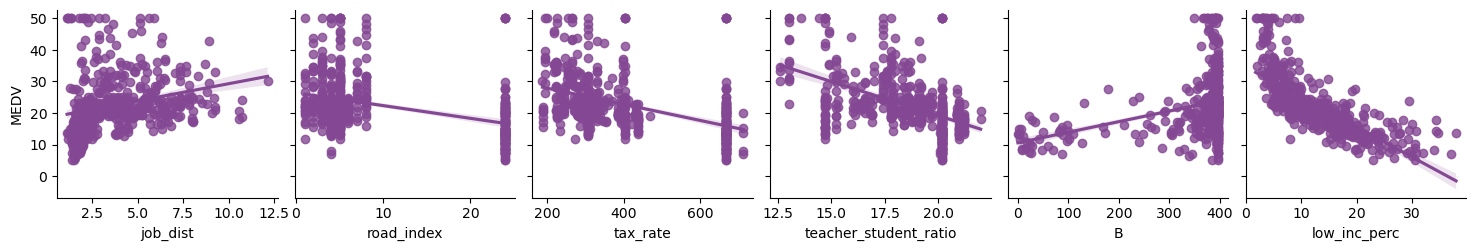

In [6]:
sns.set_palette("PRGn")
cols = ['job_dist',
 'road_index',
 'tax_rate',
 'teacher_student_ratio',
 'B',
 'low_inc_perc','MEDV']

sns.pairplot(df_boston[cols], y_vars=['MEDV'], x_vars=cols[:-1],kind='reg',palette="purple")
plt.show()

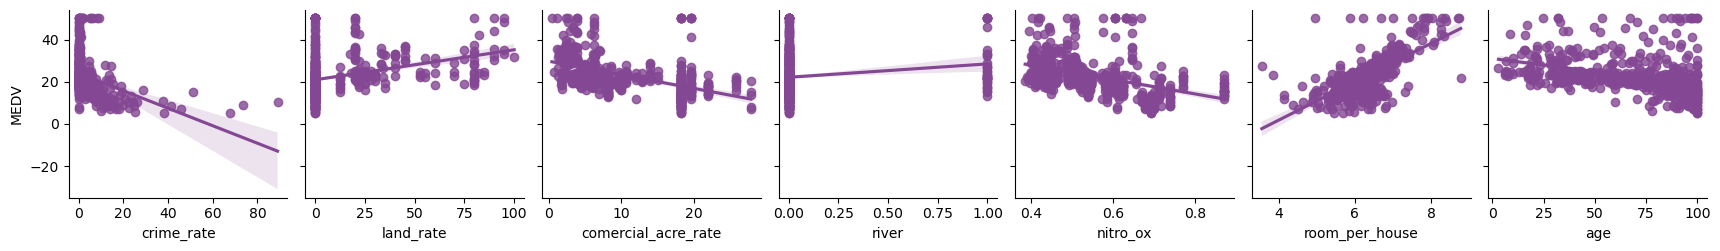

In [7]:
cols = ['crime_rate',
 'land_rate',
 'comercial_acre_rate',
 'river',
 'nitro_ox',
 'room_per_house',
 'age',
    'MEDV'
]

sns.pairplot(df_boston[cols], y_vars=['MEDV'], x_vars=cols[:-1],kind='reg',palette="purple")
plt.show()

In [8]:
X = df_boston.drop('MEDV', axis=1)
y = df_boston['MEDV']
X = sm.add_constant(X)

In [9]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=1917)

In [10]:
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=1917)


In [11]:
train_data = pd.concat([X_train, y_train], axis=1)
val_data = pd.concat([X_val, y_val], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

In [12]:
print(f"Tamaño set Entrenamiento: {len(train_data)} ({len(train_data)/len(df_boston):.0%})")
print(f"Tamaño set Validación:    {len(val_data)} ({len(val_data)/len(df_boston):.0%})")
print(f"Tamaño set Prueba:        {len(test_data)} ({len(test_data)/len(df_boston):.0%})")

Tamaño set Entrenamiento: 303 (60%)
Tamaño set Validación:    101 (20%)
Tamaño set Prueba:        102 (20%)


In [13]:
all_vars = ' + '.join(df_boston.columns.drop(['MEDV',"B"]))
formula_full = f'MEDV ~ {all_vars}'
model_full = smf.ols(formula_full, data=train_data).fit()
print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.739
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     68.45
Date:                Thu, 30 Oct 2025   Prob (F-statistic):           3.31e-77
Time:                        06:48:31   Log-Likelihood:                -898.30
No. Observations:                 303   AIC:                             1823.
Df Residuals:                     290   BIC:                             1871.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                32.32

In [14]:
y_pred_test = model_full.predict(X_test)

In [15]:
r2_test = r2_score(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_pred_test)

In [16]:
residuos = model_full.resid
y_pred_train = model_full.fittedvalues
train = train_data
exog_vars = model_full.model.exog 

In [17]:
r2_test = r2_score(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_pred_test)

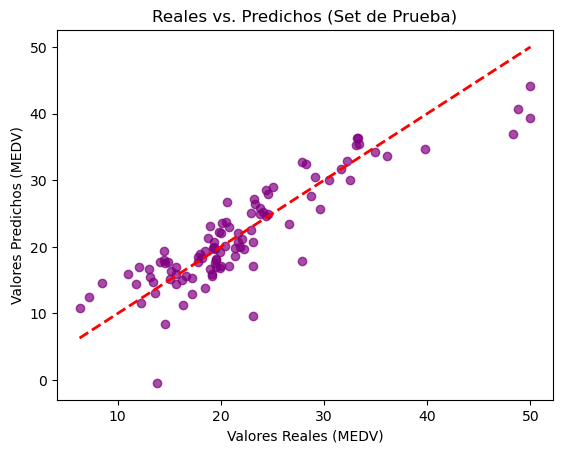

Métricas en el Conjunto de Prueba:
Coeficiente de Determinación (R²): 0.7750
Error Cuadrático Medio (MSE):       15.9683
Raíz del Error Cuadrático Medio (RMSE): 3.9960
Error Absoluto Medio (MAE):         2.9581


In [18]:
plt.scatter(y_test, y_pred_test, alpha=0.7, color="purple")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reales (MEDV)')
plt.ylabel('Valores Predichos (MEDV)')
plt.title('Reales vs. Predichos (Set de Prueba)')
plt.show()
print(f"Métricas en el Conjunto de Prueba:")
print(f"Coeficiente de Determinación (R²): {r2_test:.4f}")
print(f"Error Cuadrático Medio (MSE):       {mse_test:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_test:.4f}")
print(f"Error Absoluto Medio (MAE):         {mae_test:.4f}")

In [19]:
variables_finales = X_train
vif_data = pd.DataFrame()
vif_data["Variable"] = variables_finales.columns
vif_data["VIF"] = [variance_inflation_factor(variables_finales.values, i) for i in range(variables_finales.shape[1])]
print(vif_data)

                 Variable         VIF
0                   const  558.817593
1              crime_rate    1.730270
2               land_rate    2.358419
3     comercial_acre_rate    4.015049
4                   river    1.070259
5                nitro_ox    4.554889
6          room_per_house    2.067605
7                     age    3.295477
8                job_dist    3.887650
9              road_index    7.437061
10               tax_rate    8.501874
11  teacher_student_ratio    1.826889
12                      B    1.335911
13           low_inc_perc    3.279144


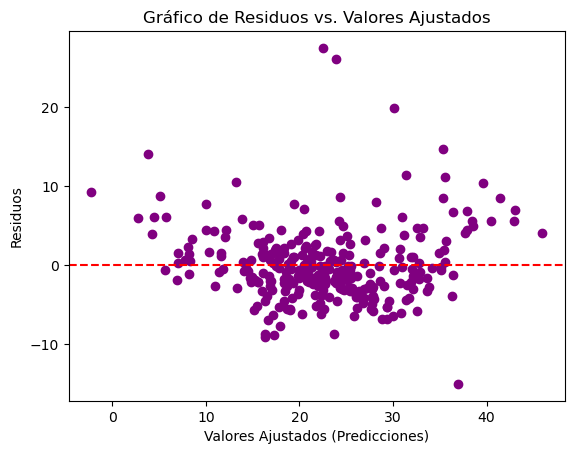

P-value (Breusch-Pagan): 0.00011707840320396679


<Figure size 640x480 with 0 Axes>

In [20]:
plt.scatter(y_pred_train, residuos, color="purple")
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores Ajustados (Predicciones)')
plt.ylabel('Residuos')
plt.title('Gráfico de Residuos vs. Valores Ajustados')
plt.show()
plt.savefig('gráfico_homocedastidad1.png')
lm, lm_pvalue, fvalue, f_pvalue = het_breuschpagan(residuos, exog_vars)
print(f'P-value (Breusch-Pagan): {f_pvalue}')

In [21]:
dw = durbin_watson(residuos)
print("Verificación de Idependencia")
print(f'Estadístico de Durbin-Watson: {dw}')

Verificación de Idependencia
Estadístico de Durbin-Watson: 1.9516649249968778


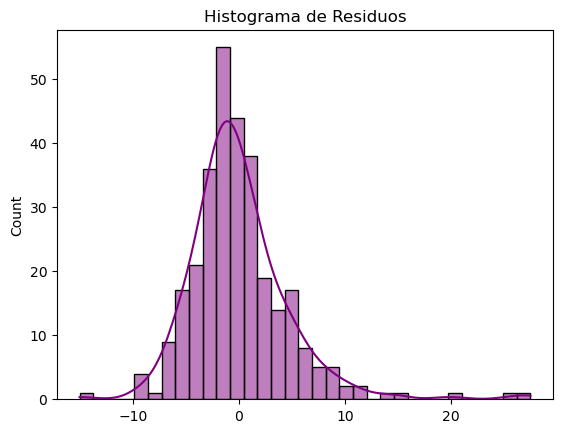

<Figure size 640x480 with 0 Axes>

In [22]:
sns.histplot(residuos, kde=True,color="purple")
plt.title('Histograma de Residuos')
plt.show()
plt.savefig('histograma_normalidad1.png')

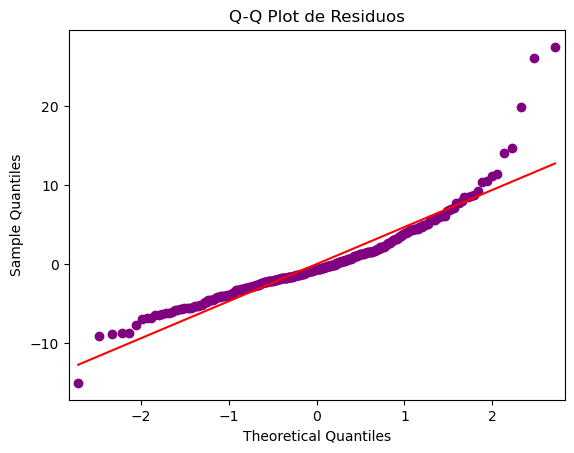

<Figure size 640x480 with 0 Axes>

In [23]:
sm.qqplot(residuos, line='s', markerfacecolor='purple', markeredgecolor='purple')
plt.title('Q-Q Plot de Residuos')
plt.show()
plt.savefig('qqplot_normalidad1.png')

In [24]:
ks_statistic, ks_pvalue = kstest_normal(residuos)
print(ks_pvalue)

0.0009999999999998899


In [25]:
model_lr = LinearRegression()
sfs = SequentialFeatureSelector(model_lr, direction='forward', n_features_to_select='auto', cv=5)
sfs.fit(X_val, y_val)
depured_x = X_val.columns[sfs.get_support()]
print("\nVariables seleccionadas por forward selection:")
print(depured_x.tolist())


Variables seleccionadas por forward selection:
['land_rate', 'job_dist', 'road_index', 'tax_rate', 'teacher_student_ratio', 'B', 'low_inc_perc']


In [26]:
formula_selected = "MEDV ~ low_inc_perc + room_per_house + crime_rate + comercial_acre_rate + land_rate" 
model_selected = smf.ols(formula_selected, data=train_data).fit()
print(model_selected.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.661
Model:                            OLS   Adj. R-squared:                  0.655
Method:                 Least Squares   F-statistic:                     115.8
Date:                Thu, 30 Oct 2025   Prob (F-statistic):           1.29e-67
Time:                        06:48:34   Log-Likelihood:                -937.96
No. Observations:                 303   AIC:                             1888.
Df Residuals:                     297   BIC:                             1910.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -4.4252    

In [27]:
y_val_pred_full = model_full.predict(X_val)
rmse_val_full = np.sqrt(mean_squared_error(y_val, y_val_pred_full))

In [28]:
y_val_pred_selected = model_selected.predict(X_val)
rmse_val_selected = np.sqrt(mean_squared_error(y_val, y_val_pred_selected))

In [29]:
residuos = model_selected.resid
y_pred_train = model_selected.fittedvalues
train = train_data
exog_vars = model_selected.model.exog 


In [30]:
variables_finales = X_train[formula_selected.split(' ~ ')[1].split(' + ')]
vif_data = pd.DataFrame()
vif_data["Variable"] = variables_finales.columns
vif_data["VIF"] = [variance_inflation_factor(variables_finales.values, i) for i in range(variables_finales.shape[1])]
print(vif_data)

              Variable       VIF
0         low_inc_perc  6.481190
1       room_per_house  6.054495
2           crime_rate  1.480754
3  comercial_acre_rate  6.618005
4            land_rate  1.774427


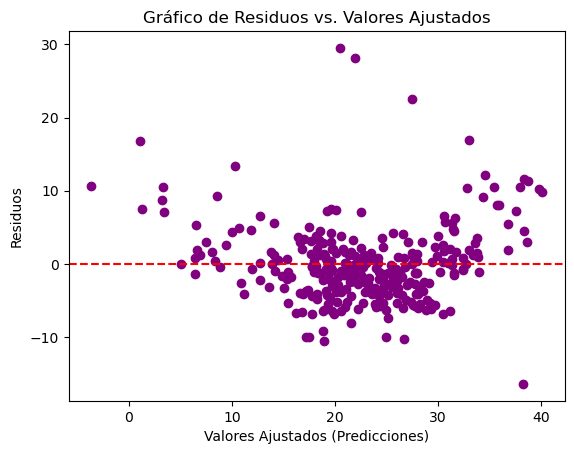

P-value (Breusch-Pagan): 0.06578165976468124


<Figure size 640x480 with 0 Axes>

In [31]:
plt.scatter(y_pred_train, residuos, color="purple")
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores Ajustados (Predicciones)')
plt.ylabel('Residuos')
plt.title('Gráfico de Residuos vs. Valores Ajustados')
plt.show()
plt.savefig('gráfico_homocedastidad.png')
lm, lm_pvalue, fvalue, f_pvalue = het_breuschpagan(residuos, exog_vars)
print(f'P-value (Breusch-Pagan): {f_pvalue}')

In [32]:
dw = durbin_watson(residuos)
print("Verificación de Idependencia")
print(f'Estadístico de Durbin-Watson: {dw}')

Verificación de Idependencia
Estadístico de Durbin-Watson: 1.8817884604371713


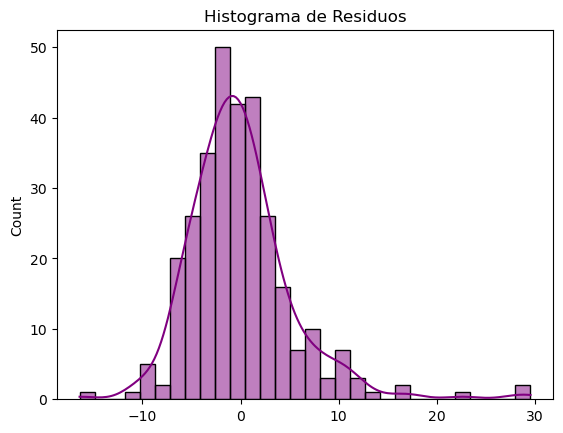

<Figure size 640x480 with 0 Axes>

In [33]:
sns.histplot(residuos, kde=True,color="purple")
plt.title('Histograma de Residuos')
plt.show()
plt.savefig('histograma_normalidad.png')

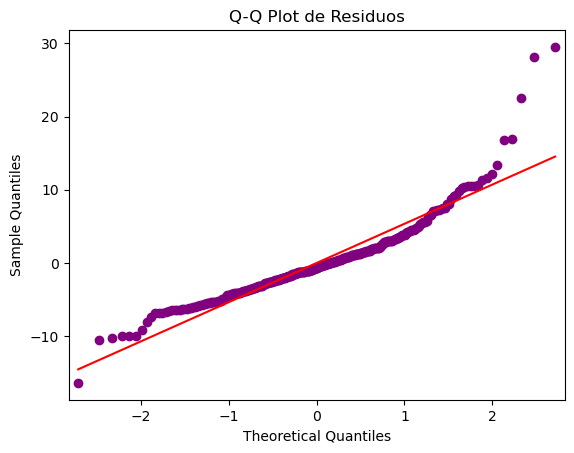

<Figure size 640x480 with 0 Axes>

In [34]:
sm.qqplot(residuos, line='s', markerfacecolor='purple', markeredgecolor='purple')
plt.title('Q-Q Plot de Residuos')
plt.show()
plt.savefig('qqplot_normalidad.png')

In [35]:
ks_statistic, ks_pvalue = kstest_normal(residuos)
print(ks_pvalue)

0.0009999999999998899


In [36]:
y_pred_test = model_selected.predict(X_test)

In [37]:
r2_test = r2_score(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_pred_test)

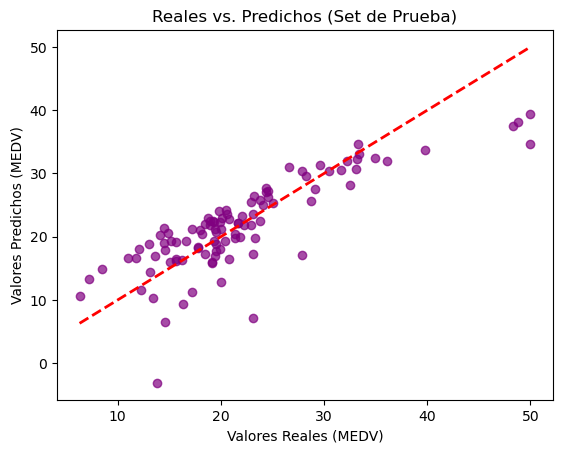

Métricas en el Conjunto de Prueba:
Coeficiente de Determinación (R²): 0.6777
Error Cuadrático Medio (MSE):       22.8721
Raíz del Error Cuadrático Medio (RMSE): 4.7825
Error Absoluto Medio (MAE):         3.4916


In [38]:
plt.scatter(y_test, y_pred_test, alpha=0.7, color="purple")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reales (MEDV)')
plt.ylabel('Valores Predichos (MEDV)')
plt.title('Reales vs. Predichos (Set de Prueba)')
plt.show()
print(f"Métricas en el Conjunto de Prueba:")
print(f"Coeficiente de Determinación (R²): {r2_test:.4f}")
print(f"Error Cuadrático Medio (MSE):       {mse_test:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_test:.4f}")
print(f"Error Absoluto Medio (MAE):         {mae_test:.4f}")